# Part 1 : La Régression Linéaire

**Durée estimée : 2h**

## 🎯 Objectifs d'apprentissage

À la fin de cette partie, vous serez capable de :
1. **Expliquer** l'intuition derrière la régression linéaire (tracer la "meilleure ligne")
2. **Interpréter** les coefficients d'un modèle de régression
3. **Appliquer** la régression linéaire avec scikit-learn sur des données réelles
4. **Identifier** quand la régression linéaire est appropriée (et quand elle ne l'est pas)

---

## 🌍 Problème Réel : Comment Zillow estime-t-il le prix de votre maison ?

Imaginez : vous voulez vendre votre appartement. Avant même de contacter une agence, vous ouvrez **Zillow** (ou SeLoger en France) et en quelques secondes, le site vous donne une estimation : **245 000 €**.

**Question :** Comment le site peut-il connaître la valeur de VOTRE appartement, qu'il n'a jamais visité ?

*(Prenez 30 secondes pour réfléchir avant de lire la suite...)*

<details>
<summary>🤔 Votre intuition ?</summary>

### 🔑 Réponse

Zillow utilise les **ventes passées** de propriétés similaires pour prédire le prix de la vôtre. Si des appartements de 50m² dans votre quartier se sont vendus autour de 5 000 €/m², alors votre appartement de 50m² vaut probablement environ 250 000 €.

C'est exactement ce que fait la **régression linéaire** : trouver une relation mathématique entre des caractéristiques (surface, nombre de pièces, quartier) et un résultat (prix).

</details>

### Le Zestimate de Zillow : un cas d'étude réel

Selon [Zillow Research](https://www.zillow.com/research/zestimate-forecast-methodology/), leur algorithme **Zestimate** analyse **7,5 millions de modèles statistiques** pour estimer la valeur de plus de 110 millions de propriétés aux États-Unis.

Le cœur de leur approche ? La **régression** : prédire un nombre (le prix) à partir de caractéristiques connues.

| Caractéristique | Impact sur le prix |
|-----------------|-------------------|
| Surface (m²) | +5 000 €/m² |
| Nombre de chambres | +15 000 €/chambre |
| Distance métro | -2 000 €/km |
| Année de construction | Variable |

**Question :** Si chaque caractéristique a un "impact" sur le prix, comment les combiner pour obtenir une estimation finale ?

*(Réponse attendue : On additionne les impacts de chaque caractéristique)*

---

## 1.1 Intuition : Tracer la "Meilleure Ligne"

Commençons par le cas le plus simple : **une seule caractéristique**.

Imaginons que vous avez les données de 5 appartements vendus récemment :

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

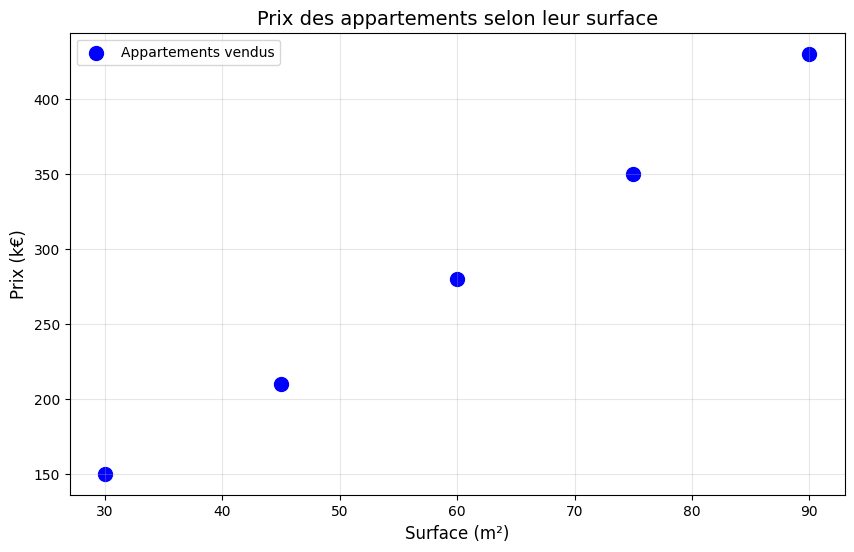

In [1]:
# Données de 5 appartements
# 1. Tes données (tableaux numpy 1D)
surface = np.array([30, 45, 60, 75, 90])  # en m²
prix = np.array([150, 210, 280, 350, 430])  # en milliers d'euros

# Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(surface, prix, s=100, c='blue', label='Appartements vendus')
plt.xlabel('Surface (m²)', fontsize=12)
plt.ylabel('Prix (k€)', fontsize=12)
plt.title('Prix des appartements selon leur surface', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Question Socratique :** En regardant ce graphique, voyez-vous une tendance ? Si un ami vous demandait d'estimer le prix d'un appartement de 50 m², comment feriez-vous ?

*(Réponse attendue : Les points semblent alignés. Je tracerais mentalement une ligne et je regarderais où 50 m² tombe sur cette ligne — probablement autour de 240-250 k€)*

### La ligne qui "passe au mieux" par les points

Votre intuition est exactement ce que fait la régression linéaire : **trouver la ligne qui passe au mieux par tous les points**.

Mais comment définir "au mieux" ?

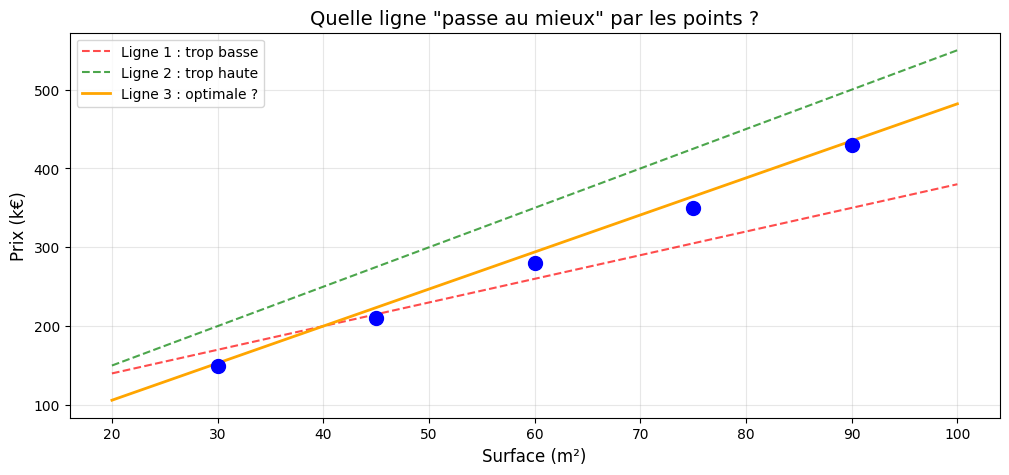

In [2]:
# Trois lignes candidates
plt.figure(figsize=(12, 5))

# Données
plt.scatter(surface, prix, s=100, c='blue', zorder=5)

# Ligne 1 : trop basse
x_line = np.linspace(20, 100, 100)
plt.plot(x_line, 3*x_line + 80, 'r--', label='Ligne 1 : trop basse', alpha=0.7)

# Ligne 2 : trop haute  
plt.plot(x_line, 5*x_line + 50, 'g--', label='Ligne 2 : trop haute', alpha=0.7)

# Ligne 3 : juste bien (approximation)
plt.plot(x_line, 4.7*x_line + 12, 'orange', linewidth=2, label='Ligne 3 : optimale ?')

plt.xlabel('Surface (m²)', fontsize=12)
plt.ylabel('Prix (k€)', fontsize=12)
plt.title('Quelle ligne "passe au mieux" par les points ?', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<details>
<summary>🤔 Question Socratique : Comment mesurer si une ligne est "bonne" ?</summary>

### 🔑 Réponse

On mesure la **distance entre chaque point et la ligne**. Une bonne ligne minimise ces distances.

Plus précisément, on mesure la **distance verticale** (l'erreur de prédiction) : pour chaque appartement, on compare le prix **réel** au prix **prédit** par la ligne.

```
Erreur = Prix réel - Prix prédit
```

La meilleure ligne est celle qui minimise la somme de toutes ces erreurs (au carré, pour pénaliser les grosses erreurs).

</details>

### Visualiser les erreurs (résidus)

In [14]:
# La "vraie" ligne optimale (calculée par régression)

# 2. Transformation obligatoire pour Scikit-Learn
# On transforme la ligne horizontale [30, 45...] en colonne verticale
X = surface.reshape(-1, 1)  # Devient 2D : (5 lignes, 1 colonne)
y = prix                    # La cible reste 1D, c'est OK

# 3. Entraînement (Sur tout le monde, pour la démo)
model = LinearRegression()
model.fit(X, y)

#⚠️ Attention : Ici, on utilise toutes les données pour entraîner le modèle car nous n'avons que 5 exemples et nous voulons juste comprendre comment la ligne se trace.
# Dans la vraie vie (Projet réel), c'est INTERDIT. Si vous faites ça, c'est comme donner les réponses de l'examen aux élèves avant l'épreuve

# 4. Visualisation
print(f"Formule trouvée : Prix = {model.coef_[0]:.2f} * Surface + {model.intercept_:.2f}")

Formule trouvée : Prix = 4.67 * Surface + 4.00


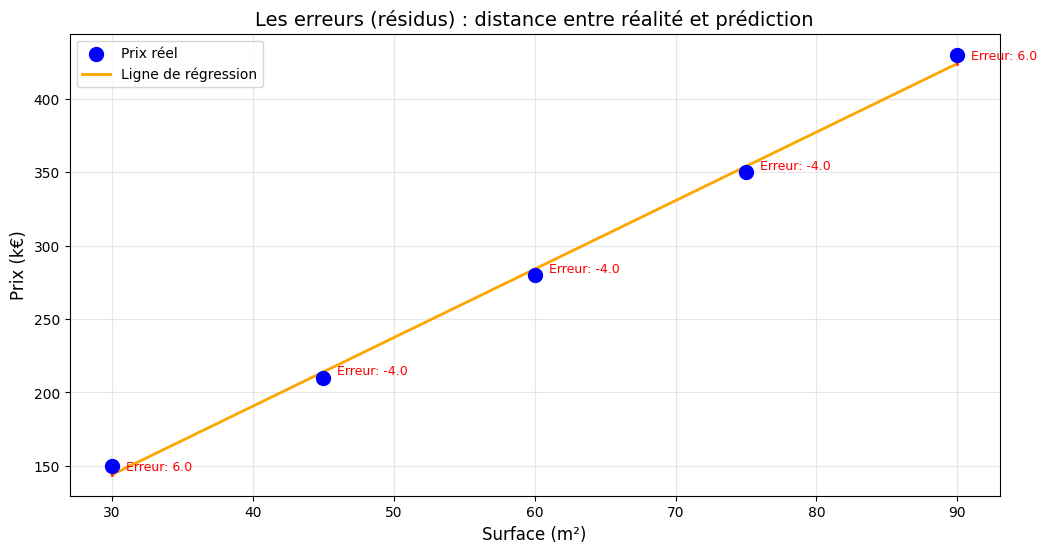

Erreurs : [ 6. -4. -4. -4.  6.]
Somme des erreurs au carré : 120.00


In [15]:
# Prédictions
prix_predit = model.predict(X)

# Visualisation avec erreurs
plt.figure(figsize=(12, 6))
plt.scatter(surface, prix, s=100, c='blue', zorder=5, label='Prix réel')
plt.plot(surface, prix_predit, 'orange', linewidth=2, label='Ligne de régression')

# Tracer les erreurs (résidus)
for i in range(len(surface)):
    plt.plot([surface[i], surface[i]], [prix[i], prix_predit[i]], 
             'r-', linewidth=2, alpha=0.7)
    plt.annotate(f'Erreur: {prix[i] - prix_predit[i]:.1f}', 
                 xy=(surface[i]+1, (prix[i] + prix_predit[i])/2),
                 fontsize=9, color='red')

plt.xlabel('Surface (m²)', fontsize=12)
plt.ylabel('Prix (k€)', fontsize=12)
plt.title('Les erreurs (résidus) : distance entre réalité et prédiction', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Erreurs : {prix - prix_predit}")
print(f"Somme des erreurs au carré : {np.sum((prix - prix_predit)**2):.2f}")

---

## 1.2 Comment ça apprend : Les Moindres Carrés

Vous venez de découvrir le principe fondamental : la régression linéaire trouve la ligne qui **minimise la somme des erreurs au carré**.

### Pourquoi "au carré" ?

**Question :** Si on avait juste additionné les erreurs (sans les mettre au carré), quel problème aurait-on ?

*(Réponse attendue : Les erreurs positives et négatives s'annuleraient ! Une erreur de +10 et une de -10 donneraient une somme de 0, alors que les prédictions sont mauvaises)*

### L'équation de la droite

Toute droite peut s'écrire sous la forme :

```
y = w × x + b
```

Où :
- **y** (La Cible) = ce qu'on prédit (le prix)
- **x** (La Feature) = la donnée d'entrée (la surface)
- **w** (Le Coefficient / Poids) = la **pente** , il indique à quel point x influence y (de combien y augmente quand x augmente de 1)
- **b** (L'Ordonnée à l'origine / Biais) = C'est le point où la droite croise l'axe vertical quand x=0. C'est la valeur de base de y même si il n'y as pas de données d'entrée (la valeur de y quand x = 0)

```
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│     Prix (y)                                                │
│       ▲                                                     │
│       │                              ╱                      │
│       │                           ╱                         │
│       │                        ╱   ← pente (w) = combien    │
│       │                     ╱        le prix augmente       │
│       │                  ╱           par m² supplémentaire  │
│       │               ╱                                     │
│       │            ╱                                        │
│       │         ╱                                           │
│     b ├──────╱   ← ordonnée à l'origine                     │
│       │    ╱       (prix de base)                           │
│       └────────────────────────────────▶ Surface (x)        │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

In [4]:
# Afficher les paramètres trouvés par le modèle
print("═" * 50)
print("PARAMÈTRES DU MODÈLE DE RÉGRESSION")
print("═" * 50)
print(f"\n  Pente (w)            : {model.coef_[0]:.2f} k€/m²")
print(f"  Ordonnée à l'origine : {model.intercept_:.2f} k€")
print(f"\n  Équation : Prix = {model.coef_[0]:.2f} × Surface + {model.intercept_:.2f}")
print("\n" + "═" * 50)

══════════════════════════════════════════════════
PARAMÈTRES DU MODÈLE DE RÉGRESSION
══════════════════════════════════════════════════

  Pente (w)            : 4.67 k€/m²
  Ordonnée à l'origine : 4.00 k€

  Équation : Prix = 4.67 × Surface + 4.00

══════════════════════════════════════════════════


<details>
<summary>🤔 Question Socratique : Que signifie concrètement une pente de 4.67 ?</summary>

### 🔑 Réponse

Une pente de **4.67 k€/m²** signifie que :

> Pour chaque mètre carré supplémentaire, le prix augmente d'environ **4 670 €**.

C'est l'**interprétation du coefficient** — et c'est une des forces majeures de la régression linéaire : les coefficients ont un **sens business direct**.

Un agent immobilier pourrait dire : "Dans ce quartier, le mètre carré vaut environ 4 700 €."

#### Analogie simple pour comprendre :

Imaginons que tu prédises le prix d'une pizza () en fonction de :

1. Son diamètre ()
2. Le nombre d'ingrédients ()

Après le `model.fit()`, tu obtiens :

* `model.intercept_` = **5.00** (C'est le prix de base de la pâte, même sans rien dessus).
* `model.coef_` = **[0.5, 1.5]**
* **0.5** : Chaque centimètre de diamètre ajoute 0.50€.
* **1.5** : Chaque ingrédient supplémentaire ajoute 1.50€.

</details>

### Prédire un nouveau prix

In [5]:
# Prédire le prix d'un appartement de 55 m²
nouvelle_surface = 55
prix_estime = model.predict([[nouvelle_surface]])[0]

print(f"\n🏠 Estimation pour un appartement de {nouvelle_surface} m² :")
print(f"   Prix estimé = {model.coef_[0]:.2f} × {nouvelle_surface} + {model.intercept_:.2f}")
print(f"   Prix estimé = {prix_estime:.1f} k€")
print(f"   Soit environ {prix_estime * 1000:.0f} €")


🏠 Estimation pour un appartement de 55 m² :
   Prix estimé = 4.67 × 55 + 4.00
   Prix estimé = 260.7 k€
   Soit environ 260667 €


```markdwon
┌─────────────────────────────────────────────────────────────────────────┐
│ 📖 DÉFINITION : Régression Linéaire Simple                              │
│                                                                         │
│ La **régression linéaire simple** est une méthode statistique qui       │
│ modélise la relation entre une variable explicative (x) et une variable │
│ cible (y) par une équation de droite : y = wx + b.                      │
│                                                                         │
│ Le modèle apprend les paramètres w (pente) et b (ordonnée à l'origine)  │
│ en minimisant la somme des carrés des écarts entre les valeurs          │
│ observées et les valeurs prédites (méthode des **moindres carrés**).    │
│                                                                         │
│ • w (pente) : impact de x sur y — combien y change quand x augmente de 1│
│ • b (intercept) : valeur de y quand x = 0                               │
└─────────────────────────────────────────────────────────────────────────┘
```

l'ordinateur a passé son temps à chercher les meilleurs a et b possibles pour chaque X pour que la droite passe le plus près possible de tes points de données.

---

## 1.3 Interprétation des Coefficients : La Régression Multiple

Dans la réalité, le prix d'un appartement dépend de **plusieurs** caractéristiques, pas seulement de la surface.

C'est là qu'intervient la **régression linéaire multiple** :

```
Prix = w₁ × Surface + w₂ × Chambres + w₃ × Distance_métro + ... + b
```

Chaque caractéristique a son propre **coefficient** (son propre impact sur le prix).

Grâce à ces deux attributs (`coef_` et `intercept_`), ton modèle n'est plus une "boîte noire". Tu peux expliquer **pourquoi** il a prédit tel chiffre. C'est ce qu'on appelle **l'interprétabilité**.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Créer un dataset plus réaliste
np.random.seed(42)
n = 100

data = pd.DataFrame({
    'surface': np.random.uniform(25, 120, n),
    'chambres': np.random.randint(1, 5, n),
    'etage': np.random.randint(0, 10, n),
    'distance_metro': np.random.uniform(0.1, 3, n),  # en km
    'annee_construction': np.random.randint(1960, 2023, n)
})

# Générer le prix selon une formule "vraie" + bruit
data['prix'] = (
    4.5 * data['surface'] +           # 4500€/m²
    25 * data['chambres'] +            # 25k€ par chambre
    3 * data['etage'] +                # 3k€ par étage
    -15 * data['distance_metro'] +     # -15k€ par km du métro
    0.5 * (data['annee_construction'] - 1960) +  # Plus récent = plus cher
    np.random.normal(0, 20, n)         # Bruit aléatoire
)

print("Aperçu des données :")
data.head(10)

Aperçu des données :


,surface,chambres,etage,distance_metro,annee_construction,prix
0,60.581311,3,0,2.938789,1964,293.089318
1,115.317859,4,0,1.511552,1981,599.647310
2,94.539424,3,2,2.727686,1988,498.552335
3,81.872556,1,1,1.359744,2014,432.081352
4,39.821771,4,4,1.115227,1962,282.709836
5,39.819479,1,9,1.970800,1971,218.751944
6,30.517943,4,5,2.039880,1985,221.638530
7,107.286734,4,6,2.606086,1975,586.734106
8,82.105926,2,3,0.767537,2010,452.998349
9,92.266895,1,6,1.547661,1996,438.783556


In [ ]:
# Séparer features et target
X = data.drop('prix', axis=1)
y = data['prix']

# Split train/test (rappel du Chapitre 2 !)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Entraîner le modèle
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

In [7]:
# Afficher les coefficients
print("\n" + "═" * 60)
print("COEFFICIENTS DU MODÈLE DE RÉGRESSION MULTIPLE")
print("═" * 60)

coef_df = pd.DataFrame({
    'Caractéristique': X.columns,
    'Coefficient': model_multi.coef_,
    'Interprétation': [
        f"+{model_multi.coef_[0]:.1f} k€ par m² supplémentaire",
        f"+{model_multi.coef_[1]:.1f} k€ par chambre supplémentaire",
        f"+{model_multi.coef_[2]:.1f} k€ par étage supplémentaire",
        f"{model_multi.coef_[3]:.1f} k€ par km du métro (négatif !)",
        f"+{model_multi.coef_[4]:.2f} k€ par année de construction récente"
    ]
})

print(coef_df.to_string(index=False))
print(f"\nOrdonnée à l'origine (b) : {model_multi.intercept_:.2f} k€")
print("═" * 60)


════════════════════════════════════════════════════════════
COEFFICIENTS DU MODÈLE DE RÉGRESSION MULTIPLE
════════════════════════════════════════════════════════════
   Caractéristique  Coefficient                             Interprétation
           surface     4.390503              +4.4 k€ par m² supplémentaire
          chambres    27.186520        +27.2 k€ par chambre supplémentaire
             etage     3.877760           +3.9 k€ par étage supplémentaire
    distance_metro   -15.775824       -15.8 k€ par km du métro (négatif !)
annee_construction     0.293320 +0.29 k€ par année de construction récente

Ordonnée à l'origine (b) : -565.77 k€
════════════════════════════════════════════════════════════


### Lecture des coefficients : une compétence business essentielle

**Question :** En regardant ces coefficients, quel conseil donneriez-vous à un investisseur immobilier ?

*(Réponse attendue : Acheter des appartements proches du métro (coefficient négatif pour la distance) et récents. La surface reste le facteur dominant.)*

<details>
<summary>🤔 Question Socratique : Pourquoi le coefficient de "distance_metro" est-il négatif ?</summary>

### 🔑 Réponse

Un coefficient **négatif** signifie une relation **inverse** : quand la distance au métro **augmente**, le prix **diminue**.

C'est logique ! Un appartement à 100m du métro vaut plus cher qu'un appartement identique à 3km.

Le coefficient de **-15.4** signifie : chaque kilomètre supplémentaire de distance au métro fait **baisser** le prix d'environ **15 400 €**.

</details>

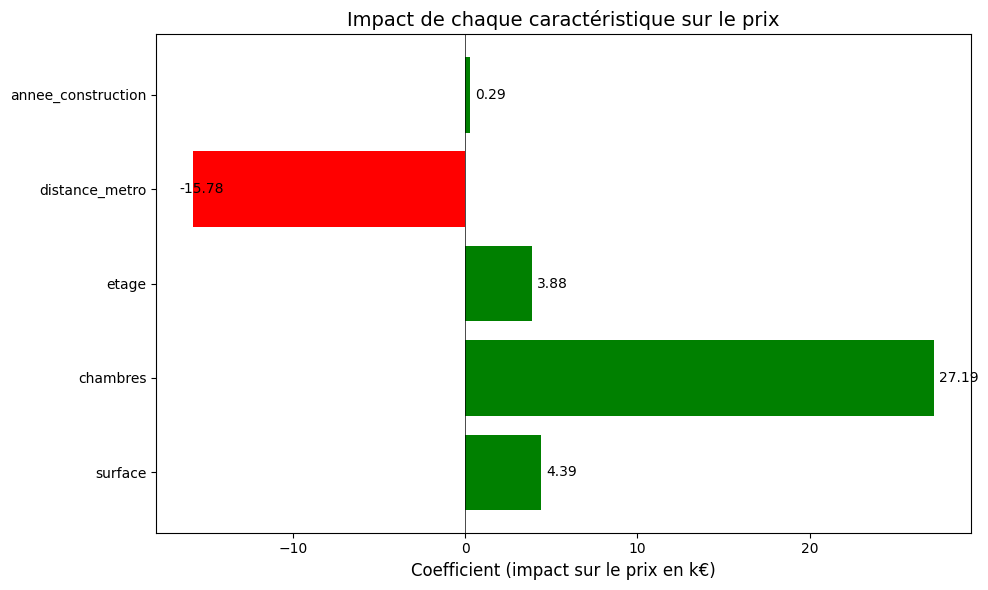

In [8]:
# Visualiser l'importance des coefficients
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in model_multi.coef_]
plt.barh(X.columns, model_multi.coef_, color=colors)
plt.xlabel('Coefficient (impact sur le prix en k€)', fontsize=12)
plt.title('Impact de chaque caractéristique sur le prix', fontsize=14)
plt.axvline(x=0, color='black', linewidth=0.5)

# Annoter
for i, (coef, col) in enumerate(zip(model_multi.coef_, X.columns)):
    plt.annotate(f'{coef:.2f}', xy=(coef + 0.3 if coef > 0 else coef - 0.8, i),
                 fontsize=10, va='center')

plt.tight_layout()
plt.show()

---

## 1.4 Hypothèses et Limites : Quand NE PAS utiliser la régression linéaire

La régression linéaire est puissante, mais elle repose sur des **hypothèses**. Si ces hypothèses ne sont pas respectées, le modèle donnera de mauvais résultats.

### Hypothèse 1 : La relation doit être LINÉAIRE

**Question :** Regardez ces deux graphiques. Sur lequel la régression linéaire fonctionnerait-elle bien ?

/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_17520/3084167578.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_17520/3084167578.py:27: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/safae/.universal_kernel/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/safae/.universal_kernel/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


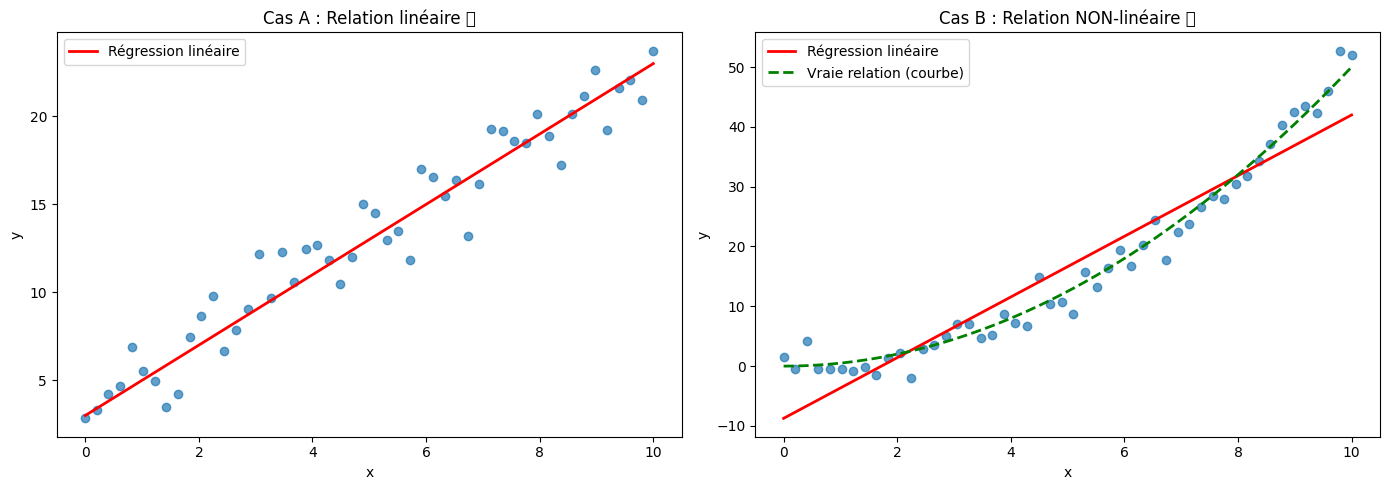

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cas 1 : Relation linéaire
x1 = np.linspace(0, 10, 50)
y1 = 2*x1 + 3 + np.random.normal(0, 1.5, 50)
axes[0].scatter(x1, y1, alpha=0.7)
axes[0].plot(x1, 2*x1 + 3, 'r-', linewidth=2, label='Régression linéaire')
axes[0].set_title('Cas A : Relation linéaire ✅', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()

# Cas 2 : Relation non-linéaire (quadratique)
x2 = np.linspace(0, 10, 50)
y2 = 0.5*x2**2 + np.random.normal(0, 2, 50)
axes[1].scatter(x2, y2, alpha=0.7)
# Ligne linéaire (mauvaise)
coef = np.polyfit(x2, y2, 1)
axes[1].plot(x2, coef[0]*x2 + coef[1], 'r-', linewidth=2, label='Régression linéaire')
# Courbe quadratique (bonne)
axes[1].plot(x2, 0.5*x2**2, 'g--', linewidth=2, label='Vraie relation (courbe)')
axes[1].set_title('Cas B : Relation NON-linéaire ❌', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()

plt.tight_layout()
plt.show()

*(Réponse : Cas A uniquement ! Dans le cas B, la régression linéaire rate complètement la vraie relation.)*

### Hypothèse 2 : Pas de multicollinéarité

**Multicollinéarité** = quand deux caractéristiques sont très corrélées entre elles.

**Exemple problématique :**
- Surface en m²
- Surface en pieds carrés (juste une conversion !)

La régression linéaire essaie d'isoler l'impact de chaque variable : "Si j'augmente la surface de 1m², de combien le prix augmente-t-il ?"

Mais si deux colonnes disent la même chose (ex: Surface en m² et Surface en pieds carrés) :
- Quand l'une augmente, l'autre augmente automatiquement.
- Le modèle ne peut plus tester l'effet de l'une sans l'autre.
- Mathématiquement, cela crée une instabilité : les coefficients (a,b,c...) peuvent devenir énormes ou changer totalement si on enlève juste une ligne de données.

Si ces deux variables sont dans le modèle, les coefficients deviennent instables et difficiles à interpréter.
Pour que le modèle soit stable, chaque colonne doit apporter une information unique."

### Hypothèse 3 : Résidus normalement distribués (homoscédasticité)

Les erreurs du modèle doivent être :
- Aléatoires (pas de pattern)
- De variance constante

Si les erreurs montrent un pattern, le modèle rate quelque chose.

1. Le concept de "Erreur Aléatoire"

Imagine que ton modèle est un tireur à l'arc.

* Si ses flèches arrivent un peu partout autour du centre, c'est **aléatoire**. Le modèle est bon, c'est juste de l'imprécision naturelle.
* Si toutes ses flèches arrivent 10 cm trop haut à droite, il y a un **pattern**. Le modèle a un problème de réglage (ou il n'a pas pris en compte le vent).

2. La Variance Constante vs La "Trompette"

C'est ça, l'homoscédasticité. C'est l'idée que le modèle doit être **aussi précis pour les petits chiffres que pour les grands**.

* **Le bon scénario (Homoscédasticité) :** Que l'appartement fasse 20 m² ou 200 m², le modèle se trompe en moyenne de 5 000 €. L'erreur est stable.
* **Le mauvais scénario (Hétéroscédasticité) :** Le modèle est super précis pour les petits studios (erreur de 1 000 €), mais il devient complètement fou pour les villas de luxe (erreur de 200 000 €).

3. Comment l'expliquer simplement avec un graphique ?

le graphique des **résidus** (la différence entre le vrai prix et le prix prédit) :

* ✅ **Ciel étoilé :** Si les points sont éparpillés comme des étoiles dans le ciel, sans forme précise, c'est parfait. **Homoscédasticité !**
* ❌ **La Trompette :** Si les points dessinent un éventail qui s'ouvre, c'est mauvais. **Hétéroscédasticité !**

**L'Histogramme** des résidus : Si le modèle est bon, ses erreurs doivent suivre une loi normale (la fameuse cloche de Gauss) :

* Le sommet au centre (sur 0) : Cela veut dire que la majorité des prédictions tombent pile poil sur le bon prix (erreur = 0). C'est ce qu'on veut !
* La symétrie : Le modèle doit se tromper autant en "trop cher" qu'en "pas assez cher".

> "L'homoscédasticité, c'est quand le modèle est **juste pour tout le monde**. S'il commence à faire des erreurs géantes uniquement sur les gros chiffres, c'est qu'il a raté une information capitale. Un bon modèle ne doit pas avoir de favoris."

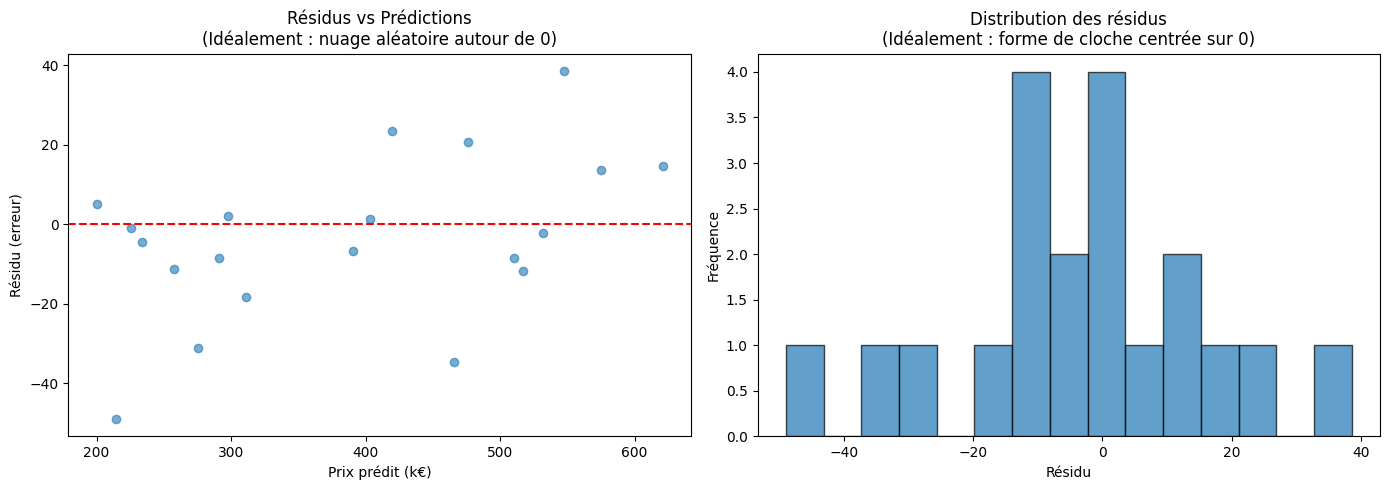

In [10]:
# Vérifier les résidus de notre modèle
y_pred = model_multi.predict(X_test)
residus = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Résidus vs Prédictions
axes[0].scatter(y_pred, residus, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Prix prédit (k€)')
axes[0].set_ylabel('Résidu (erreur)')
axes[0].set_title('Résidus vs Prédictions\n(Idéalement : nuage aléatoire autour de 0)')

# Distribution des résidus
axes[1].hist(residus, bins=15, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Résidu')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus\n(Idéalement : forme de cloche centrée sur 0)')

plt.tight_layout()
plt.show()

### 📋 Résumé : Quand utiliser (ou éviter) la régression linéaire

| Situation | Régression linéaire ? |
|-----------|----------------------|
| Prédire un prix, un coût, une température | ✅ Oui |
| Relation clairement linéaire dans les données | ✅ Oui |
| Besoin d'interpréter l'impact de chaque variable | ✅ Oui (coefficients) |
| Relation en forme de U ou de courbe | ❌ Non (transformer les données ou autre modèle) |
| Variables très corrélées entre elles | ⚠️ Attention (supprimer les redondances) |
| Prédire une catégorie (oui/non, spam/pas spam) | ❌ Non → Régression logistique (Part 2) |

---

## 🧪 Exercice Pratique : Prédire le prix des maisons Boston

Appliquez ce que vous avez appris sur un vrai dataset !

In [11]:
# Charger un dataset réel (California Housing)
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X_cal = pd.DataFrame(california.data, columns=california.feature_names)
y_cal = california.target * 100  # Prix en milliers de $

print("Dataset California Housing")
print(f"Nombre d'observations : {len(X_cal)}")
print(f"\nCaractéristiques disponibles :")
for col in X_cal.columns:
    print(f"  - {col}")

X_cal.head()

Dataset California Housing
Nombre d'observations : 20640

Caractéristiques disponibles :
  - MedInc
  - HouseAge
  - AveRooms
  - AveBedrms
  - Population
  - AveOccup
  - Latitude
  - Longitude


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### Votre mission :

1. Séparez les données en train/test (80/20)
2. Entraînez un modèle de régression linéaire
3. Affichez les coefficients et interprétez-les
4. Quel facteur a le plus d'impact sur le prix ?

In [12]:
# 🎯 À VOUS DE JOUER !

# Étape 1 : Split train/test
# X_train, X_test, y_train, y_test = ...

# Étape 2 : Créer et entraîner le modèle
# model = ...
# model.fit(...)

# Étape 3 : Afficher les coefficients
# ...

# Étape 4 : Interpréter

## 🔑 Réponse à l'exercice

In [13]:
# Solution

# Étape 1 : Split
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)

# Étape 2 : Entraîner
model_cal = LinearRegression()
model_cal.fit(X_train_cal, y_train_cal)

# Étape 3 : Coefficients
coefs = pd.DataFrame({
    'Feature': X_cal.columns,
    'Coefficient': model_cal.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Coefficients triés par importance (valeur absolue) :")
print(coefs.to_string(index=False))

# Étape 4 : Score
score = model_cal.score(X_test_cal, y_test_cal)
print(f"\nR² sur test : {score:.3f}")
print(f"Le modèle explique {score*100:.1f}% de la variance des prix.")

Coefficients triés par importance (valeur absolue) :
   Feature  Coefficient
 AveBedrms    78.314491
    MedInc    44.867491
 Longitude   -43.370806
  Latitude   -41.979249
  AveRooms   -12.332334
  HouseAge     0.972426
  AveOccup    -0.352632
Population    -0.000203

R² sur test : 0.576
Le modèle explique 57.6% de la variance des prix.


/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


---

## 📚 Récapitulatif

### Ce que vous avez appris :

1. **Intuition** : La régression linéaire trouve la "meilleure ligne" qui passe par les points
2. **Méthode** : Elle minimise la somme des erreurs au carré (moindres carrés)
3. **Équation** : y = w₁x₁ + w₂x₂ + ... + b
4. **Interprétation** : Chaque coefficient = impact de cette variable sur y
5. **Limites** : Nécessite une relation linéaire, pas de multicollinéarité

### Code essentiel :

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Paramètres appris
print(model.coef_)        # Coefficients (pentes)
print(model.intercept_)   # Ordonnée à l'origine

# Prédire
predictions = model.predict(X_test)

# Évaluer
r2 = model.score(X_test, y_test)
```

### Prochaine partie : Régression Logistique

Et si on voulait prédire non pas un **nombre** mais une **catégorie** (spam/pas spam, frauduleux/légitime) ? C'est le sujet de la Part 2 !

---

## 🤔 Réflexion Métacognitive

Avant de passer à la suite, prenez un moment pour réfléchir :

1. Quel concept de cette partie vous a semblé le plus difficile à comprendre ?
2. Pouvez-vous expliquer à quelqu'un d'autre ce que signifie un coefficient de régression ?
3. Dans votre domaine (ou futur domaine), voyez-vous une application de la régression linéaire ?

---

**Sources :**
- [Zillow Zestimate Forecast Methodology](https://www.zillow.com/research/zestimate-forecast-methodology/)
- [NumberAnalytics - Linear Regression in E-commerce](https://www.numberanalytics.com/blog/bloglinear-regression-ecommerce-case-studies)
- [scikit-learn LinearRegression Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)